In [1]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/My Drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import lightgbm as lgbm
from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, multilabel_confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
data = pd.read_csv("fish_data.csv")

In [4]:
print(data.isna().sum()) #Считаем количество NaN значений в датасете
print(data.isnull().sum()) #Считаем количество пропусков в датасете

species      0
length       0
weight       0
w_l_ratio    0
dtype: int64
species      0
length       0
weight       0
w_l_ratio    0
dtype: int64


In [5]:
print(names := np.array(list(zip(data['species'].unique(), [i for i in range(len(data['species'].unique()))]))).reshape(9, 2))

[['Anabas testudineus' '0']
 ['Coilia dussumieri' '1']
 ['Otolithoides biauritus' '2']
 ['Otolithoides pama' '3']
 ['Pethia conchonius' '4']
 ['Polynemus paradiseus' '5']
 ['Puntius lateristriga' '6']
 ['Setipinna taty' '7']
 ['Sillaginopsis panijus' '8']]


In [6]:
data['species'].replace(data['species'].unique(), [i for i in range(len(data['species'].unique()))], inplace = True)

<ipython-input-6-4bca7280e1f8>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['species'].replace(data['species'].unique(), [i for i in range(len(data['species'].unique()))], inplace = True)
<ipython-input-6-4bca7280e1f8>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['species'].replace

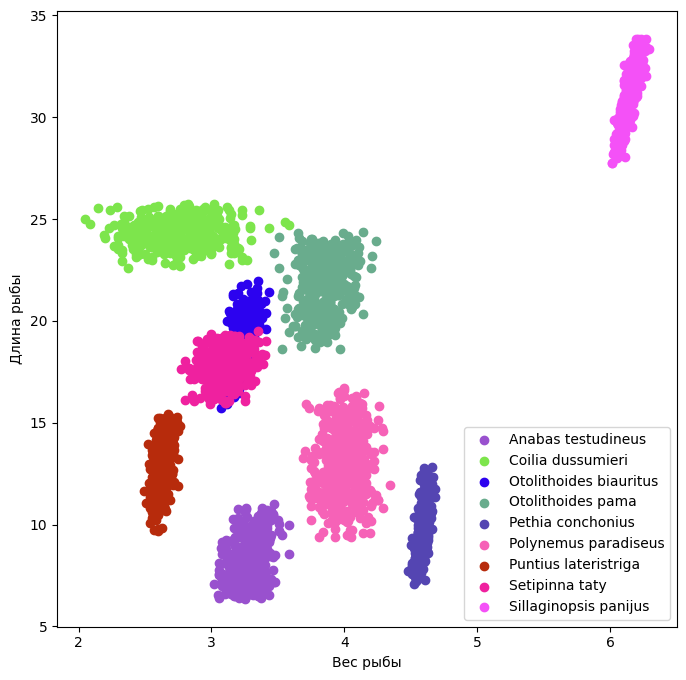

In [7]:
plt.figure(figsize=(8,8))
r = lambda: random.randint(0, 255)
colors = ['#%02X%02X%02X' % (r(), r(), r()) for i in range(len(names))]
for i in range(len(names)):
  temp = data.query(f'species == {names[i][1]}')
  plt.scatter(temp['weight'], temp['length'], label = names[i][0], c=colors[i])
plt.xlabel('Вес рыбы')
plt.ylabel('Длина рыбы')
plt.legend(loc='best')

In [8]:
X = data.drop(['species'], axis=1)
y = data.species

In [9]:
X = StandardScaler().fit_transform(X)
y_bin = label_binarize(y, classes = [*range(len(y.unique()))])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size = 0.2, random_state = 2024-10-20)

In [11]:
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 2024-10-20, shuffle=True)

#Дерево решений

In [12]:
model_tree = OneVsRestClassifier(tree.DecisionTreeClassifier(max_depth = 10))
model_tree.fit(X_train_val, y_train_val)

OneVsRestClassifier(estimator=DecisionTreeClassifier(max_depth=10))

In [13]:
pred1 = model_tree.predict(X_val)

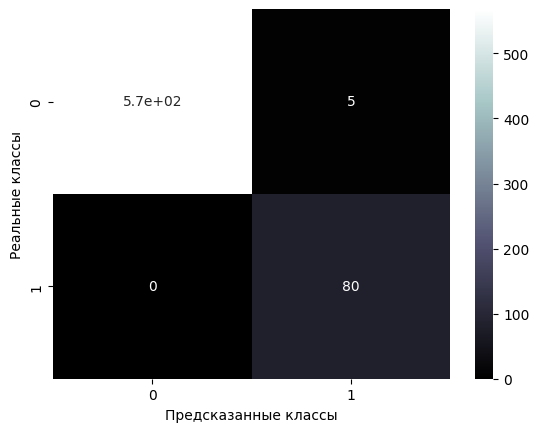

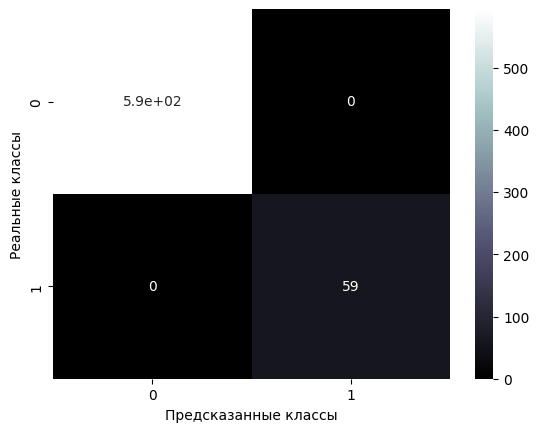

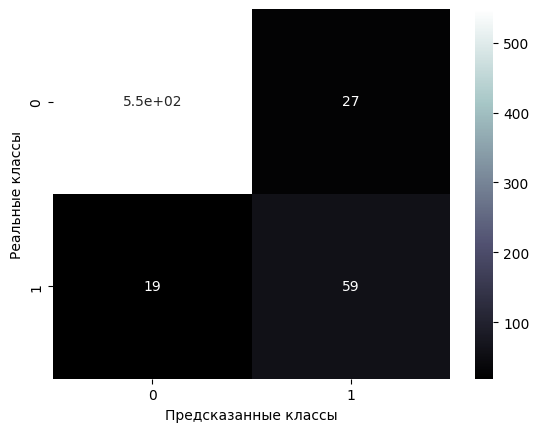

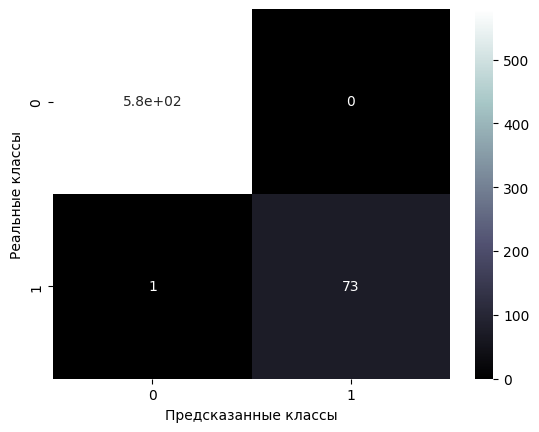

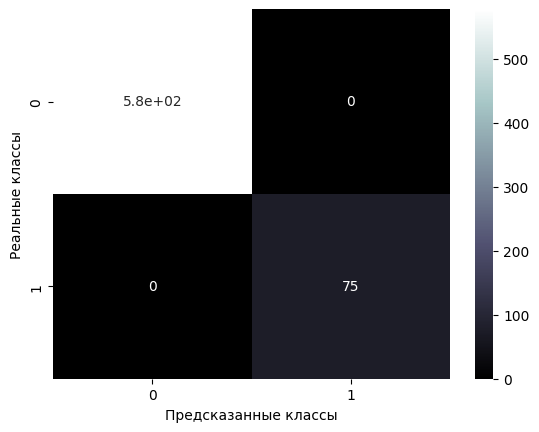

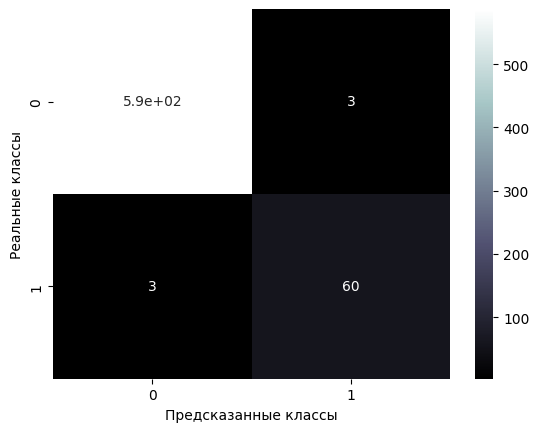

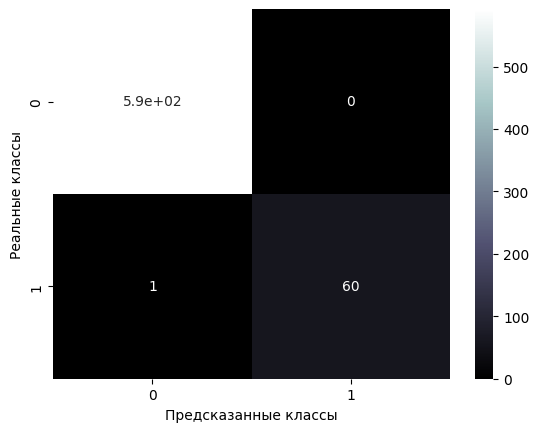

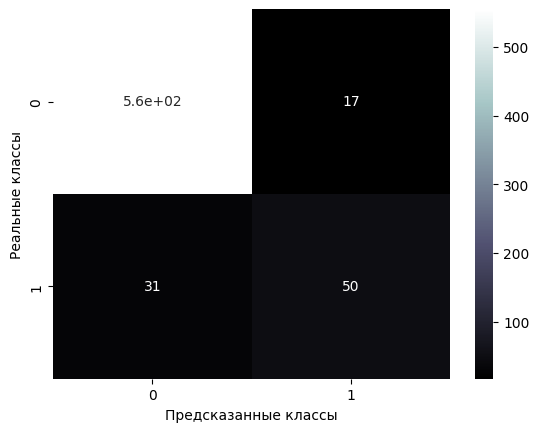

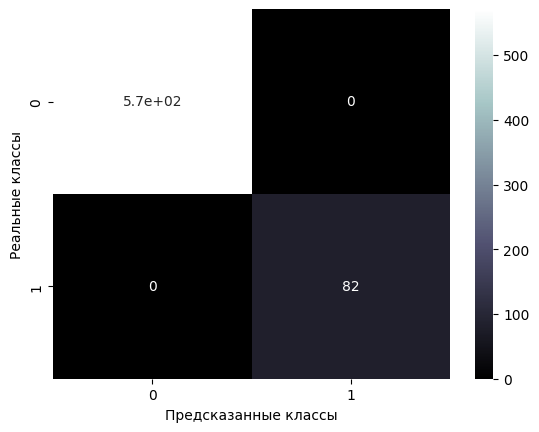

In [14]:
conf_matrix = multilabel_confusion_matrix(y_val, pred1)
for i in range(conf_matrix.shape[0]):
  sns.heatmap(conf_matrix[i], label=True, annot=True, cmap="bone")
  plt.ylabel('Реальные классы')
  plt.xlabel('Предсказанные классы')
  plt.show()

In [15]:
accuracy = accuracy_score(y_val, pred1)
f1 = f1_score(y_val, pred1, average='weighted')
print(f'Accuracy: {accuracy}')
print(f'F1-мера: {f1}')

Accuracy: 0.886676875957121
F1-мера: 0.9164163934656206


In [16]:
clf1 = GridSearchCV(model_tree, {
    'estimator__max_depth': [i for i in range(2, 100)]
}, cv=5, scoring = 'accuracy')
clf1.fit(X_train_val, y_train_val)
print(f'Лучшая метрика полученная Грид сёрчем: {clf1.best_score_}')
print(f'Параметры при которых достигнута лучшая метрика: {clf1.best_params_}')
best_params = dict(zip(["max_depth"], list(clf1.best_params_.values())))
model_tree_best_params = OneVsRestClassifier(tree.DecisionTreeClassifier(**best_params))
model_tree_best_params.fit(X_train, y_train)
best_pred_tree = model_tree_best_params.predict(X_test)
accuracy = accuracy_score(y_test, best_pred_tree)
f1 = f1_score(y_test, best_pred_tree, average='weighted')
print(f'Accuracy: {accuracy}')
print(f'F1-мера: {f1}')

Лучшая метрика полученная Грид сёрчем: 0.926077815139594
Параметры при которых достигнута лучшая метрика: {'estimator__max_depth': 6}
Accuracy: 0.8995098039215687
F1-мера: 0.9113586810846425


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


#Ансамбли. Бэггинг

In [17]:
model_rf = OneVsRestClassifier(RandomForestClassifier(random_state=2024-10-20))
model_rf.fit(X_train_val, y_train_val)

OneVsRestClassifier(estimator=RandomForestClassifier(random_state=1994))

In [18]:
pred2 = model_rf.predict(X_val)

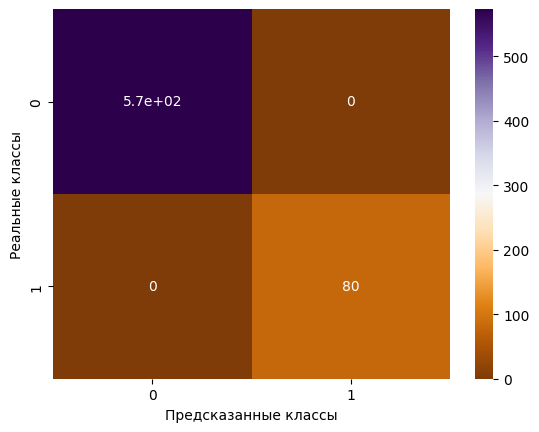

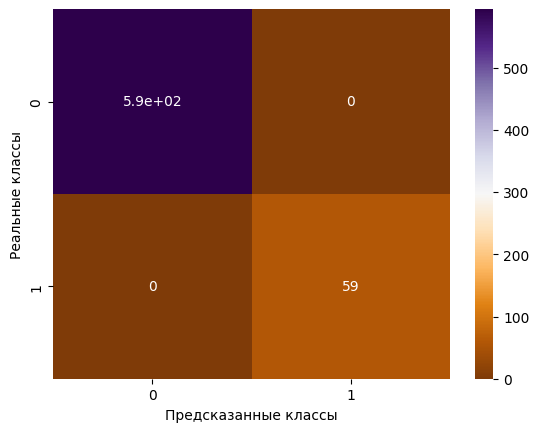

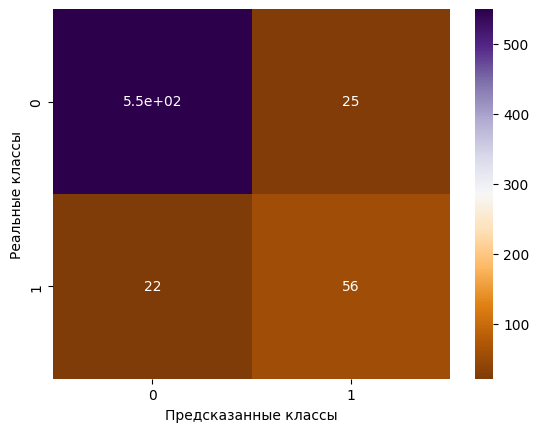

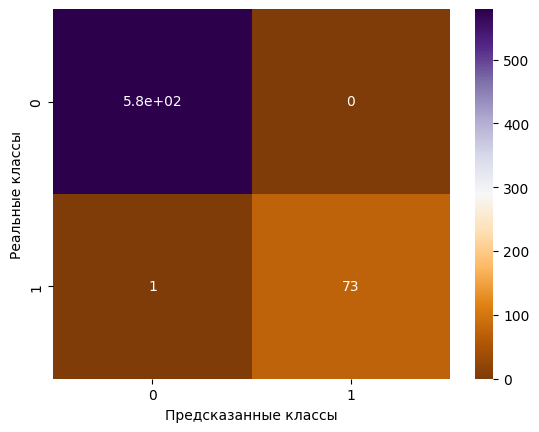

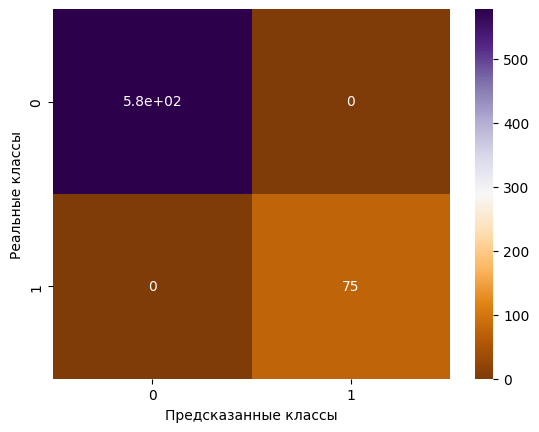

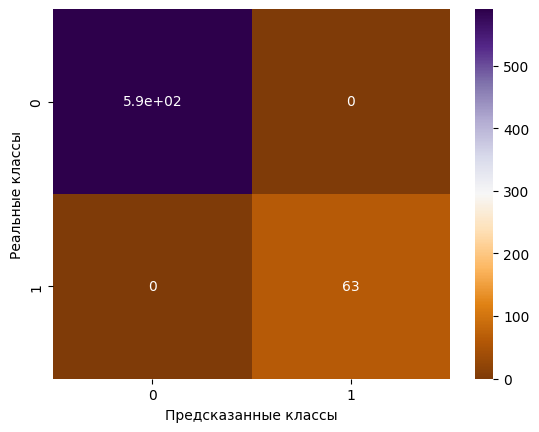

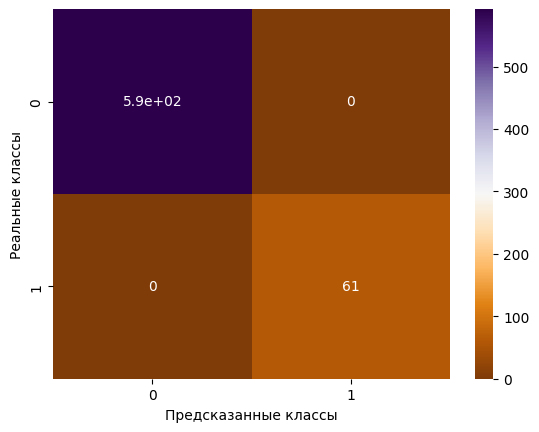

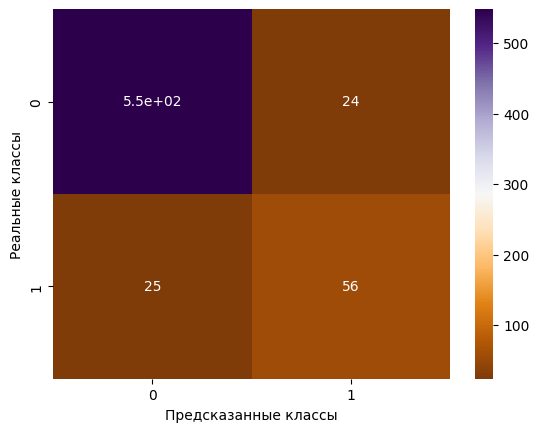

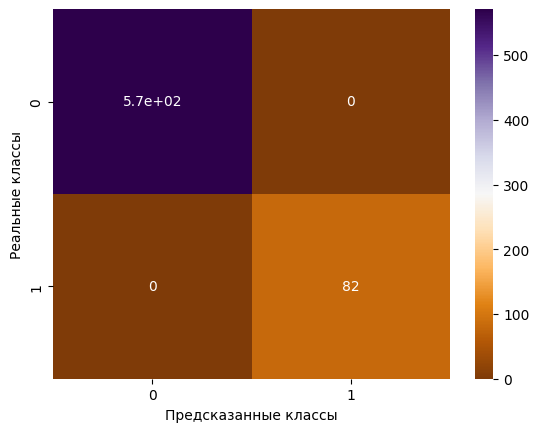

In [19]:
conf_matrix = multilabel_confusion_matrix(y_val, pred2)
for i in range(conf_matrix.shape[0]):
  sns.heatmap(conf_matrix[i], label=True, annot=True, cmap="PuOr")
  plt.ylabel('Реальные классы')
  plt.xlabel('Предсказанные классы')
  plt.show()

In [20]:
accuracy = accuracy_score(y_val, pred2)
f1 = f1_score(y_val, pred2, average='weighted')
print(f'Accuracy валидационная: {accuracy}')
print(f'F1-мера валидационная: {f1}')

Accuracy валидационная: 0.9249617151607963
F1-мера валидационная: 0.9261681791008076


In [21]:
pred2_test = model_rf.predict(X_test)
accuracy = accuracy_score(y_test, pred2_test)
f1 = f1_score(y_test, pred2_test, average='weighted')
print(f'Accuracy тестовая: {accuracy}')
print(f'F1-мера тестовая: {f1}')

Accuracy тестовая: 0.9142156862745098
F1-мера тестовая: 0.9196652667426509


#Ансамбли. Бустинг

In [22]:
model_lgbm = OneVsRestClassifier(lgbm.LGBMClassifier())
model_lgbm.fit(X_train_val, y_train_val)

[LightGBM] [Info] Number of positive: 303, number of negative: 2308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 2611, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116047 -> initscore=-2.030404
[LightGBM] [Info] Start training from score -2.030404
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

OneVsRestClassifier(estimator=LGBMClassifier())

In [23]:
pred3 = model_lgbm.predict(X_val)

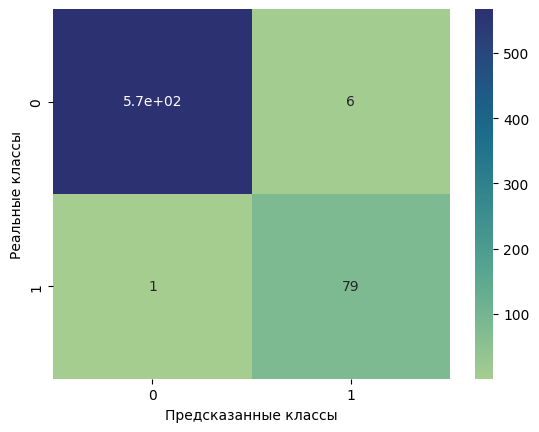

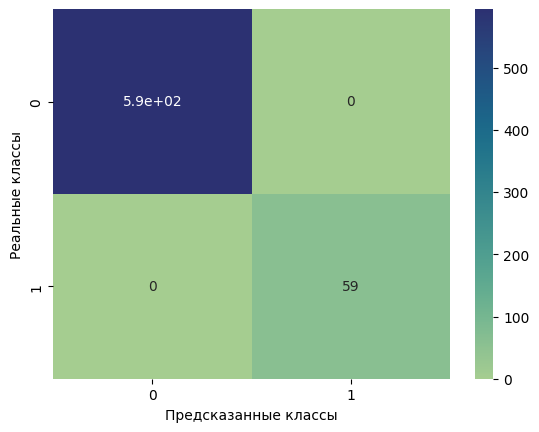

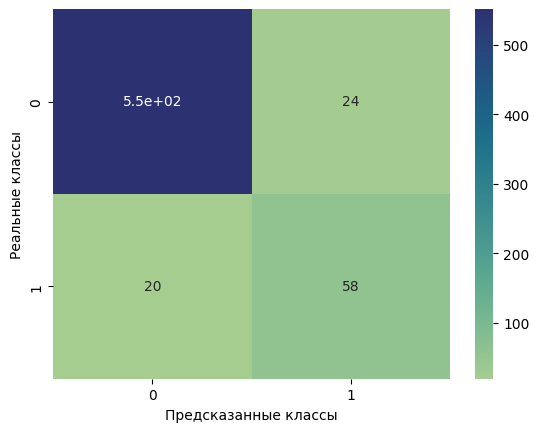

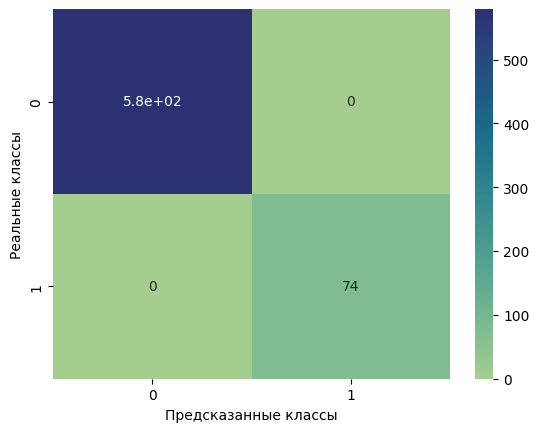

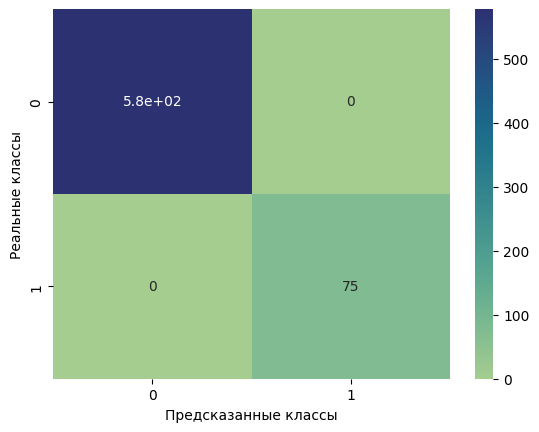

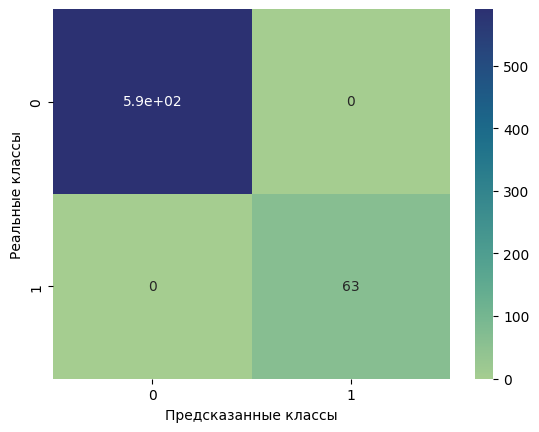

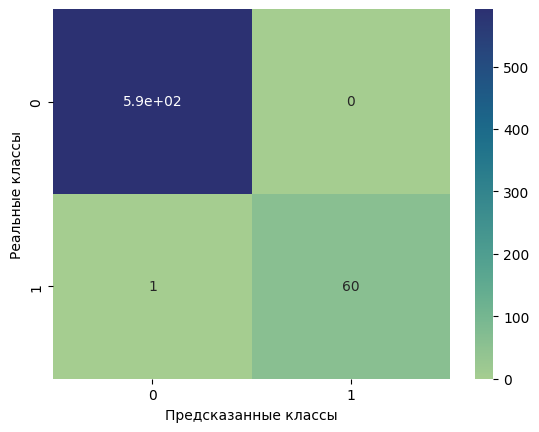

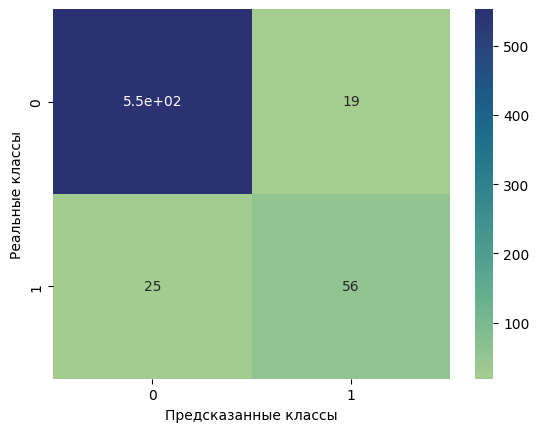

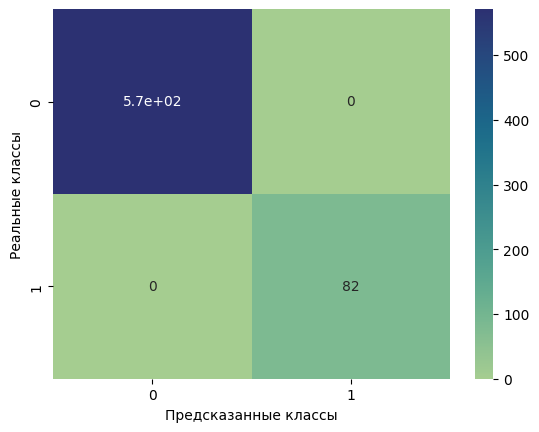

In [24]:
conf_matrix = multilabel_confusion_matrix(y_val, pred3)
for i in range(conf_matrix.shape[0]):
  sns.heatmap(conf_matrix[i], label=True, annot=True, cmap="crest")
  plt.ylabel('Реальные классы')
  plt.xlabel('Предсказанные классы')
  plt.show()

In [25]:
accuracy = accuracy_score(y_val, pred3)
f1 = f1_score(y_val, pred3, average='weighted')
print(f'Accuracy валидационная: {accuracy}')
print(f'F1-мера валидационная: {f1}')

Accuracy валидационная: 0.9096477794793262
F1-мера валидационная: 0.9261956730911207


In [26]:
pred3_test = model_lgbm.predict(X_test)
accuracy = accuracy_score(y_test, pred3_test)
f1 = f1_score(y_test, pred3_test, average='weighted')
print(f'Accuracy тестовая: {accuracy}')
print(f'F1-мера тестовая: {f1}')

Accuracy тестовая: 0.8995098039215687
F1-мера тестовая: 0.9094265973271274


#Ансамбли. Стэкинг

In [27]:
# Определение базовых моделей
base_estimators = [
 ('rf', RandomForestClassifier(n_estimators=100,
random_state=42)),
 ('dt', tree.DecisionTreeClassifier(max_depth=3,
random_state=42))
]
# Метамодель
final_estimator = LogisticRegression()
# Создание стекинг-классификатора
model_stacking = OneVsRestClassifier(StackingClassifier(estimators=base_estimators,
final_estimator=final_estimator))
model_stacking.fit(X_train_val, y_train_val)

OneVsRestClassifier(estimator=StackingClassifier(estimators=[('rf',
                                                              RandomForestClassifier(random_state=42)),
                                                             ('dt',
                                                              DecisionTreeClassifier(max_depth=3,
                                                                                     random_state=42))],
                                                 final_estimator=LogisticRegression()))

In [28]:
pred4 = model_stacking.predict(X_val)

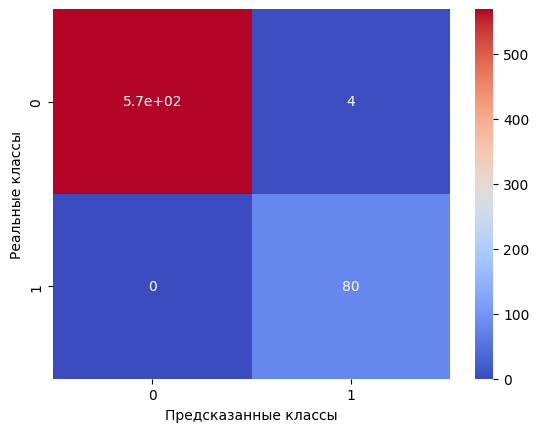

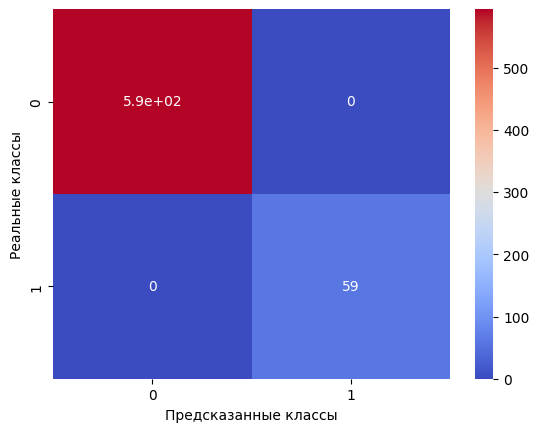

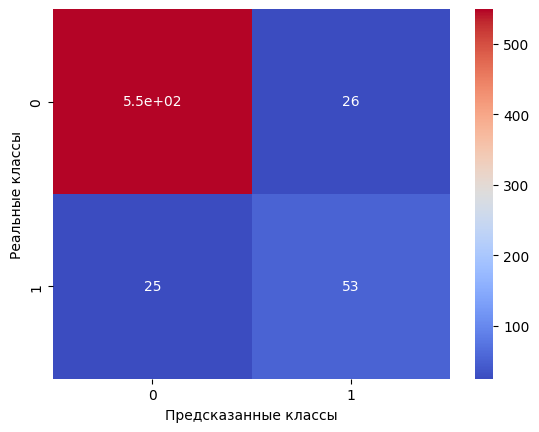

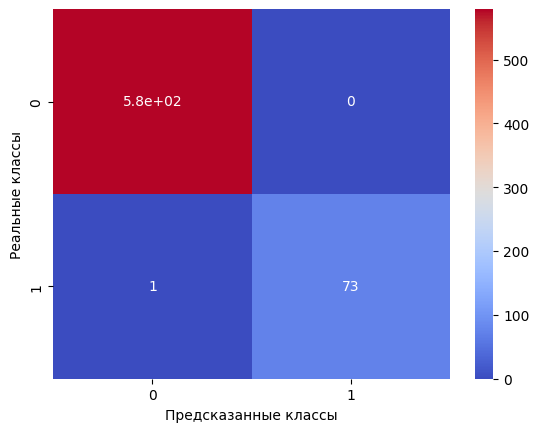

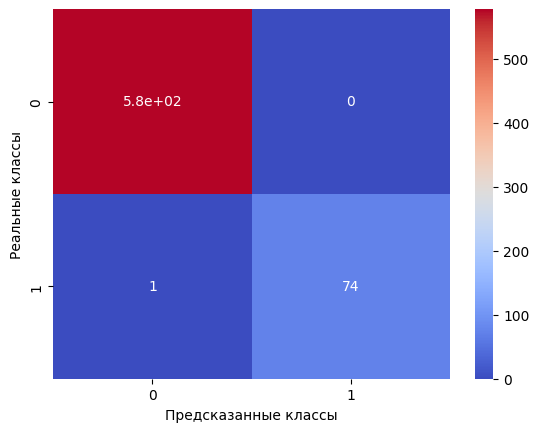

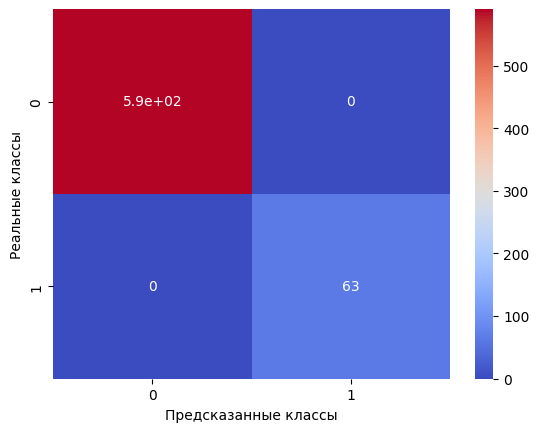

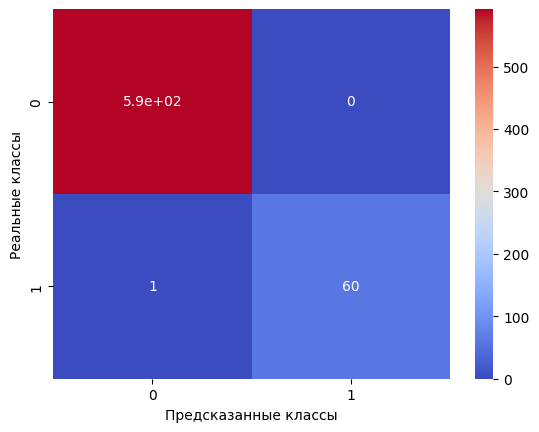

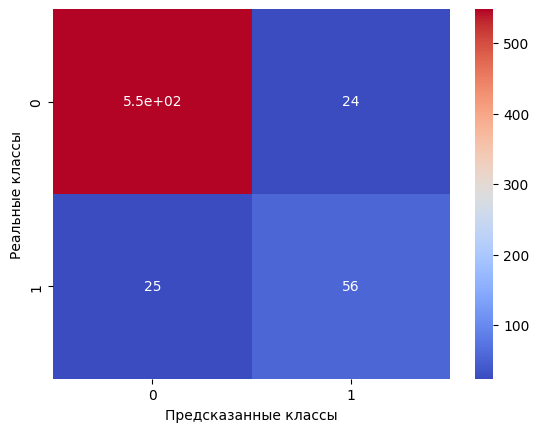

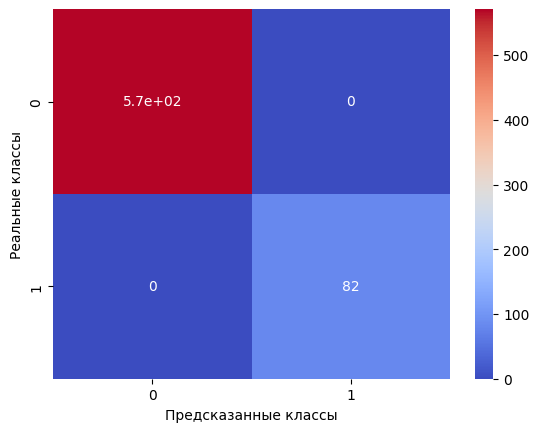

In [29]:
conf_matrix = multilabel_confusion_matrix(y_val, pred4)
for i in range(conf_matrix.shape[0]):
  sns.heatmap(conf_matrix[i], label=True, annot=True, cmap="coolwarm")
  plt.ylabel('Реальные классы')
  plt.xlabel('Предсказанные классы')
  plt.show()

In [30]:
accuracy = accuracy_score(y_val, pred4)
f1 = f1_score(y_val, pred4, average='weighted')
print(f'Accuracy валидационная: {accuracy}')
print(f'F1-мера валидационная: {f1}')

Accuracy валидационная: 0.9019908116385911
F1-мера валидационная: 0.9181441618074732


In [31]:
pred4_test = model_stacking.predict(X_test)
accuracy = accuracy_score(y_test, pred4_test)
f1 = f1_score(y_test, pred4_test, average='weighted')
print(f'Accuracy тестовая: {accuracy}')
print(f'F1-мера тестовая: {f1}')

Accuracy тестовая: 0.8848039215686274
F1-мера тестовая: 0.9053694244231778
